In [21]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
data = pd.read_csv('train.csv')
print(data.head())

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

In [23]:
print(f"veri setinin boyutu: {data.shape}")
print(f"\nveri setinin bilgileri: {data.info()}")

veri setinin boyutu: (1460, 81)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 

In [24]:
missing_data = data.isnull().sum()/len(data)*100
print(f"eksik veri yüzdeleri: {missing_data.head(10)}")

eksik veri yüzdeleri: Id              0.000000
MSSubClass      0.000000
MSZoning        0.000000
LotFrontage    17.739726
LotArea         0.000000
Street          0.000000
Alley          93.767123
LotShape        0.000000
LandContour     0.000000
Utilities       0.000000
dtype: float64


In [25]:
print(f"SalePrice istatistikleri: \n{data['SalePrice'].describe()}")

SalePrice istatistikleri: 
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [26]:
threshold = 0.8*len(data)
data_cleaned = data.loc[:,data.isnull().sum() < threshold]

print(f"temizlenmiş veri seti boyutu: {data_cleaned.shape}")

temizlenmiş veri seti boyutu: (1460, 77)


In [27]:
missing_data_cleaned = data_cleaned.isnull().sum()/len(data_cleaned)*100
print(f"temizlenmiş veri setindeki eksik veri yüzdeleri: \n{missing_data_cleaned[missing_data_cleaned > 0]}")

temizlenmiş veri setindeki eksik veri yüzdeleri: 
LotFrontage     17.739726
MasVnrType      59.726027
MasVnrArea       0.547945
BsmtQual         2.534247
BsmtCond         2.534247
BsmtExposure     2.602740
BsmtFinType1     2.534247
BsmtFinType2     2.602740
Electrical       0.068493
FireplaceQu     47.260274
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
dtype: float64


In [37]:
# Sayısal sütunları seçip eksik değerleri ortalama ile doldurma
numeric_columns = data_cleaned.select_dtypes(include=['int64', 'float64']).columns
data_cleaned.loc[:, numeric_columns] = data_cleaned[numeric_columns].fillna(data_cleaned[numeric_columns].mean())

# Eksik veri kontrolü (sayısal sütunlar için)
print("Sayısal sütunlarda kalan eksik veri yüzdeleri:")
print(data_cleaned[numeric_columns].isnull().sum() / len(data_cleaned) * 100)

Sayısal sütunlarda kalan eksik veri yüzdeleri:
Id               0.0
MSSubClass       0.0
LotFrontage      0.0
LotArea          0.0
OverallQual      0.0
OverallCond      0.0
YearBuilt        0.0
YearRemodAdd     0.0
MasVnrArea       0.0
BsmtFinSF1       0.0
BsmtFinSF2       0.0
BsmtUnfSF        0.0
TotalBsmtSF      0.0
1stFlrSF         0.0
2ndFlrSF         0.0
LowQualFinSF     0.0
GrLivArea        0.0
BsmtFullBath     0.0
BsmtHalfBath     0.0
FullBath         0.0
HalfBath         0.0
BedroomAbvGr     0.0
KitchenAbvGr     0.0
TotRmsAbvGrd     0.0
Fireplaces       0.0
GarageYrBlt      0.0
GarageCars       0.0
GarageArea       0.0
WoodDeckSF       0.0
OpenPorchSF      0.0
EnclosedPorch    0.0
3SsnPorch        0.0
ScreenPorch      0.0
PoolArea         0.0
MiscVal          0.0
MoSold           0.0
YrSold           0.0
SalePrice        0.0
dtype: float64


In [29]:
categorical_columns = data_cleaned.select_dtypes(include=['object']).columns
data_cleaned.loc[:, categorical_columns] = data_cleaned[categorical_columns].fillna(data[categorical_columns].mode().iloc[0])

print("Kategorik sütunlarda kalan eksik veri yüzdeleri:")
print(data_cleaned[categorical_columns].isnull().sum() / len(data_cleaned) * 100)

Kategorik sütunlarda kalan eksik veri yüzdeleri:
MSZoning         0.0
Street           0.0
LotShape         0.0
LandContour      0.0
Utilities        0.0
LotConfig        0.0
LandSlope        0.0
Neighborhood     0.0
Condition1       0.0
Condition2       0.0
BldgType         0.0
HouseStyle       0.0
RoofStyle        0.0
RoofMatl         0.0
Exterior1st      0.0
Exterior2nd      0.0
MasVnrType       0.0
ExterQual        0.0
ExterCond        0.0
Foundation       0.0
BsmtQual         0.0
BsmtCond         0.0
BsmtExposure     0.0
BsmtFinType1     0.0
BsmtFinType2     0.0
Heating          0.0
HeatingQC        0.0
CentralAir       0.0
Electrical       0.0
KitchenQual      0.0
Functional       0.0
FireplaceQu      0.0
GarageType       0.0
GarageFinish     0.0
GarageQual       0.0
GarageCond       0.0
PavedDrive       0.0
SaleType         0.0
SaleCondition    0.0
dtype: float64


In [30]:
data_encoded = pd.get_dummies(data_cleaned, columns= categorical_columns, drop_first=True)
print("One-hot encoding sonrası veri setinin boyutu:", data_encoded.shape)

One-hot encoding sonrası veri setinin boyutu: (1460, 237)


In [31]:
X = data_encoded.drop('SalePrice', axis = 1)
y = data_encoded['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 42)

print("Eğitim seti boyutu:", X_train.shape, y_train.shape)
print("Test seti boyutu:", X_test.shape, y_test.shape)

Eğitim seti boyutu: (1168, 236) (1168,)
Test seti boyutu: (292, 236) (292,)


In [32]:
# Veriyi PyTorch tensor'larına çevirme
X_train_tensor = torch.tensor(X_train.values.astype(np.float32), dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values.astype(np.float32), dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values.astype(np.float32), dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values.astype(np.float32), dtype=torch.float32).view(-1, 1)

# Tensor boyutlarını kontrol etme
print("X_train_tensor boyutu:", X_train_tensor.shape)
print("y_train_tensor boyutu:", y_train_tensor.shape)
print("X_test_tensor boyutu:", X_test_tensor.shape)
print("y_test_tensor boyutu:", y_test_tensor.shape)

X_train_tensor boyutu: torch.Size([1168, 236])
y_train_tensor boyutu: torch.Size([1168, 1])
X_test_tensor boyutu: torch.Size([292, 236])
y_test_tensor boyutu: torch.Size([292, 1])


In [33]:
# X_train'in tiplerini tekrar kontrol etme ve object sütunları bulma
print("X_train sütun tipleri:")
print(X_train.dtypes)

object_columns = X_train.select_dtypes(include=['object']).columns
print("Object tipindeki sütunlar:", object_columns)

# Eğer object yoksa, veriyi float'a çevirip tensor yapma
if len(object_columns) == 0:
    X_train_tensor = torch.tensor(X_train.values.astype('float32'), dtype=torch.float32)
    print("X_train_tensor boyutu:", X_train_tensor.shape)
else:
    print("Object sütunlar var, bunları düzeltmemiz lazım!")

X_train sütun tipleri:
Id                         int64
MSSubClass                 int64
LotFrontage              float64
LotArea                    int64
OverallQual                int64
                          ...   
SaleCondition_AdjLand       bool
SaleCondition_Alloca        bool
SaleCondition_Family        bool
SaleCondition_Normal        bool
SaleCondition_Partial       bool
Length: 236, dtype: object
Object tipindeki sütunlar: Index([], dtype='object')
X_train_tensor boyutu: torch.Size([1168, 236])


In [34]:
# Veriyi PyTorch tensor'larına çevirme (tüm setler için)
X_train_tensor = torch.tensor(X_train.values.astype('float32'), dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values.astype('float32'), dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values.astype('float32'), dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values.astype('float32'), dtype=torch.float32).view(-1, 1)

# Tensor boyutlarını kontrol etme
print("X_train_tensor boyutu:", X_train_tensor.shape)
print("y_train_tensor boyutu:", y_train_tensor.shape)
print("X_test_tensor boyutu:", X_test_tensor.shape)
print("y_test_tensor boyutu:", y_test_tensor.shape)

X_train_tensor boyutu: torch.Size([1168, 236])
y_train_tensor boyutu: torch.Size([1168, 1])
X_test_tensor boyutu: torch.Size([292, 236])
y_test_tensor boyutu: torch.Size([292, 1])


In [35]:
class HousePriceModel(nn.Module):
  def __init__(self, input_size):
    super().__init__()
    self.layer_stack = nn.Sequential(nn.Linear(input_size,128),
                                     nn.ReLU(),
                                     nn.Linear(128,64),
                                     nn.ReLU(),
                                     nn.Linear(64,1))
  def forward(self, x):
    return self.layer_stack(x)

input_size = X_train_tensor.shape[1]
model = HousePriceModel(input_size)

print(model)


HousePriceModel(
  (layer_stack): Sequential(
    (0): Linear(in_features=236, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)


Epoch [20/200], Loss: 0.1406
Epoch [40/200], Loss: 0.0520
Epoch [60/200], Loss: 0.0220
Epoch [80/200], Loss: 0.0101
Epoch [100/200], Loss: 0.0051
Epoch [120/200], Loss: 0.0028
Epoch [140/200], Loss: 0.0015
Epoch [160/200], Loss: 0.0008
Epoch [180/200], Loss: 0.0004
Epoch [200/200], Loss: 0.0002
Test Loss (MSE): 0.1459
Ortalama Mutlak Hata (MAE): 18387.8145


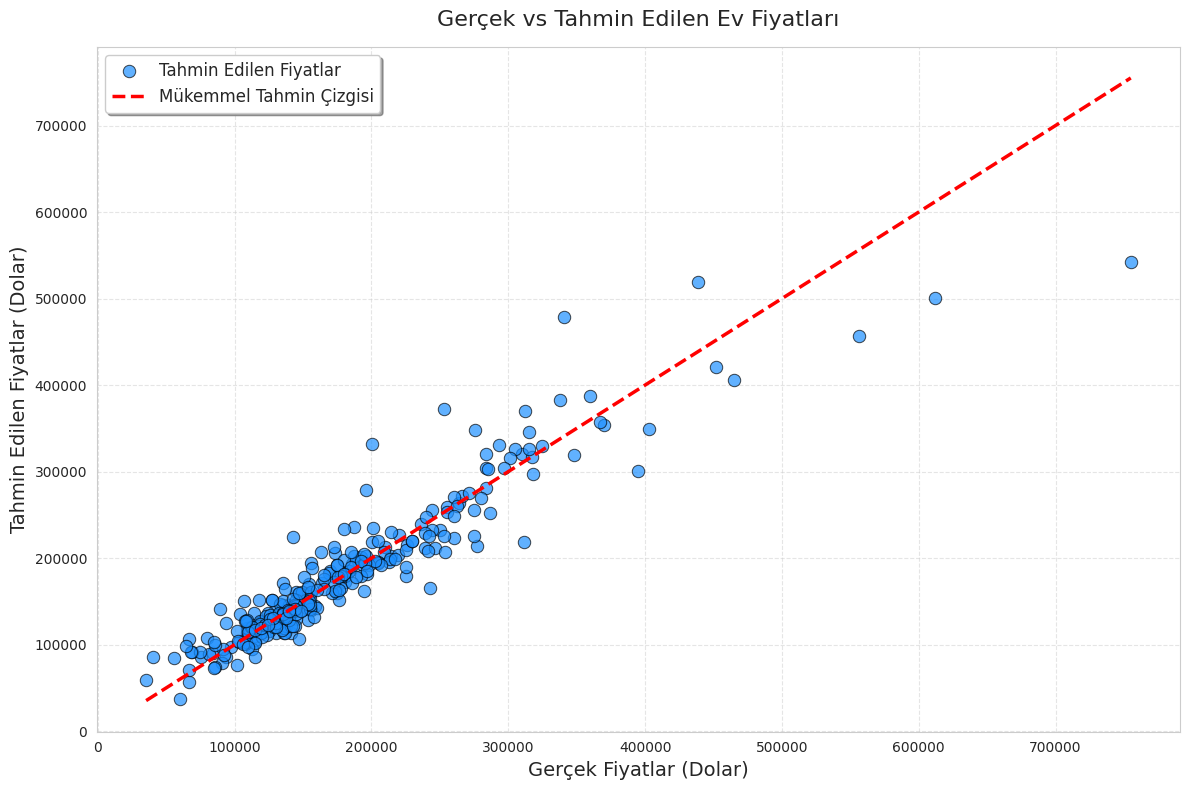

In [36]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Veri ölçeklendirme
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

# Eğitim/test bölme
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

# Tensor'lara çevirme
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# Model tanımı
class HousePriceModel(nn.Module):
    def __init__(self, input_size):
        super(HousePriceModel, self).__init__()
        self.layer_stack = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.layer_stack(x)

# Modeli oluşturma
input_size = X_train_tensor.shape[1]  # 236
model = HousePriceModel(input_size)

# Kayıp ve optimizasyon
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Eğitim döngüsü
num_epochs = 200
for epoch in range(num_epochs):
    model.train()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

# Test etme
model.eval()
with torch.no_grad():
    y_pred_tensor = model(X_test_tensor)
    test_loss = criterion(y_pred_tensor, y_test_tensor)
    print(f"Test Loss (MSE): {test_loss.item():.4f}")

# Orijinal ölçeğe çevirme
y_pred_scaled = y_pred_tensor.numpy()
y_test_scaled = y_test_tensor.numpy()
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test = scaler_y.inverse_transform(y_test_scaled)

# MAE hesaplama
mae = np.mean(np.abs(y_pred - y_test))
print(f"Ortalama Mutlak Hata (MAE): {mae:.4f}")

# Geliştirilmiş Seaborn görselleştirme
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")
sns.scatterplot(x=y_test.flatten(), y=y_pred.flatten(), label="Tahmin Edilen Fiyatlar",
                alpha=0.7, color="dodgerblue", s=80, edgecolor="black")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--',
         label="Mükemmel Tahmin Çizgisi", linewidth=2.5)
plt.xlabel("Gerçek Fiyatlar (Dolar)", fontsize=14)
plt.ylabel("Tahmin Edilen Fiyatlar (Dolar)", fontsize=14)
plt.title("Gerçek vs Tahmin Edilen Ev Fiyatları", fontsize=16, pad=15)
plt.legend(loc="upper left", fontsize=12, frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()